# Logistic Regression - Student Droput rate predection

## Member Details
- Name: Hansaja A. M. G
- Student ID: IT22171856
- Email: IT22171856@my.sliit.lk

In [2]:
# Import required libraries for Logistic Regression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
# Load the dataset from CSV
df = pd.read_csv('../../data/sample data.csv')
# Display the first 5 rows to inspect the data
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


Shape: (4424, 36)  |  Missing values: 0
Data types: {dtype('int64'): np.int64(29), dtype('float64'): np.int64(7)}

Target distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794


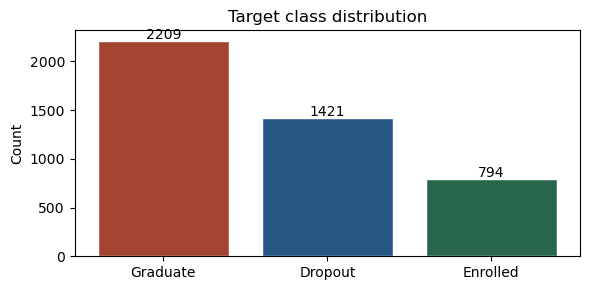

In [9]:
dataset = pd.read_csv('../../data/sample data.csv')  # Dataset
X = dataset.drop(columns=['Target'])
y = dataset['Target']

print(f"Shape: {X.shape}  |  Missing values: {X.isnull().sum().sum()}")
print(f"Data types: {dict(X.dtypes.value_counts())}")
print("\nTarget distribution:")
print(y.value_counts().to_string())

# Class distribution chart
counts = y.value_counts()
plt.figure(figsize=(6, 3))
bars = plt.bar(counts.index, counts.values, color=["#A34431","#275784","#28674C"], edgecolor='white')
for b in bars:
    plt.text(b.get_x() + b.get_width() / 2, b.get_height() + 20, str(int(b.get_height())), ha='center', fontsize=10)
plt.title('Target class distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [4]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Preprocessing: remove rows with nulls first
rows_before = len(df)
df_clean = df.dropna().copy()
rows_after = len(df_clean)

# 2. Handle categorical features with one-hot encoding
X = pd.get_dummies(df_clean.drop(columns=['Target']), drop_first=True)
y = df_clean['Target']

# Encode target labels
le = LabelEncoder()
y = le.fit_transform(y)

# 3. Split data using stratification so class balance is preserved
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Build a pipeline so scaling happens inside cross-validation folds
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=5000))
])

# 5. Hyperparameter tuning with cross-validation
param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__solver': ['lbfgs', 'liblinear'],
    'model__class_weight': [None, 'balanced']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)
search.fit(X_train, y_train)

# 6. Evaluate the best model on the test set
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)

print(f"Best CV score: {search.best_score_:.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Best CV score: 0.7663
Test Accuracy: 0.7718

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.79      0.77      0.78       284
    Enrolled       0.54      0.35      0.42       159
    Graduate       0.81      0.93      0.86       442

    accuracy                           0.77       885
   macro avg       0.71      0.68      0.69       885
weighted avg       0.75      0.77      0.76       885



In [5]:
# Save Logistic Regression Model

import pickle
import os

os.makedirs('saved_models', exist_ok=True)
logreg_bundle = {
    'pipeline':   best_model,      # Includes scaler + LogisticRegression with best hyperparams
    'encoder':    le,              # Label encoder for target classes
    'feature_columns': X.columns.tolist(),  # Feature names after preprocessing
}
with open('saved_models/logistic_regression_model.pkl', 'wb') as f:
    pickle.dump(logreg_bundle, f)
print("Logistic Regression model saved -> saved_models/logistic_regression_model.pkl")
print(f"Pipeline contains: scaler + LogisticRegression(C={search.best_params_['model__C']}, solver={search.best_params_['model__solver']})")
print(f"Encoder classes: {list(le.classes_)}")
print(f"Number of features: {len(X.columns)}")

Logistic Regression model saved -> saved_models/logistic_regression_model.pkl
Pipeline contains: scaler + LogisticRegression(C=100, solver=lbfgs)
Encoder classes: ['Dropout', 'Enrolled', 'Graduate']
Number of features: 36
